
**Датасет:** House Prices  
**Источник:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data  
**Описание:** Датасет содержит информацию о жилых домах в Эймсе, штат Айова.  
**Целевая переменная:** SalePrice - цена продажи дома.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('house_prices.csv')
print(f'первые 5 строк')
df.head()

первые 5 строк


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
print("Последние 5 строк:")
df.tail()

Последние 5 строк:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [5]:
print(f'размер массива {df.shape}')

размер массива (1460, 81)


In [6]:
print("Информация о датасете:")
df.info()

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null 

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'всего колонок: {df.shape[1]}')
print(f'колонок с пропусками: {missing.shape[0]}')
print("первые 15 колонок с пропусками")
missing.head(15)

всего колонок: 81
колонок с пропусками: 19
первые 15 колонок с пропусками


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
dtype: int64

In [8]:
print("Статитстика числовых признаков")
print(f'числовых признаков: {df.select_dtypes(include=['number']).shape[1]}')
df.describe()

Статитстика числовых признаков
числовых признаков: 38


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [9]:
print("Статистика для строк")
print(f'категориальных признаков: {df.select_dtypes(include=['object']).shape[1]}')
df.describe(include="object")

Статистика для строк
категориальных признаков: 43


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


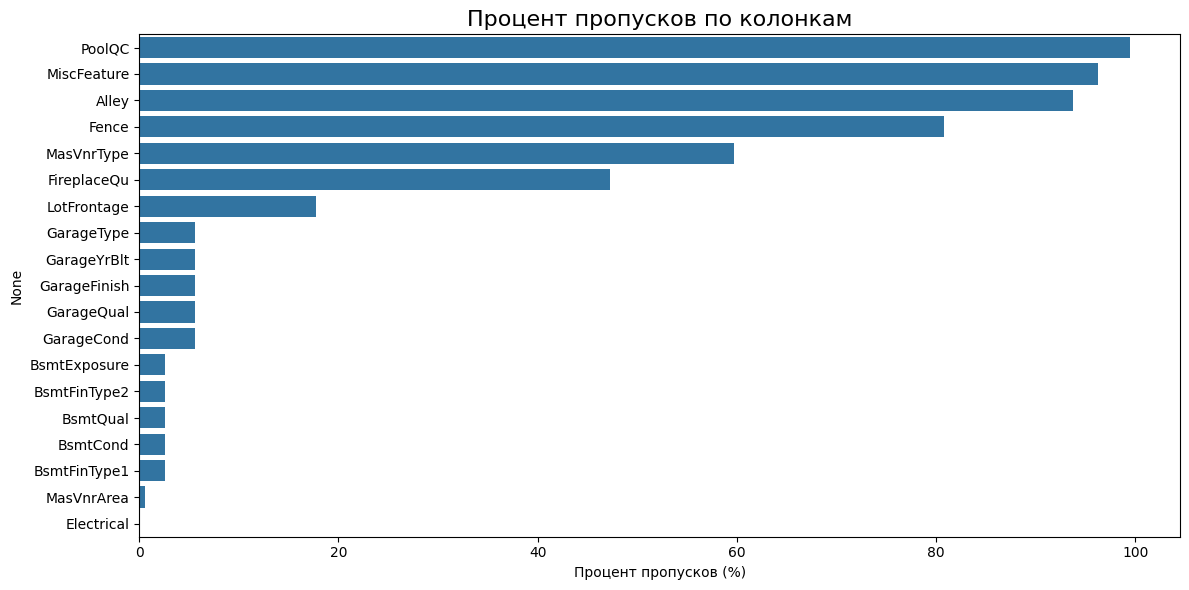

Классификация пропусков:


,Колонка,Пропусков_%,Тип_данных
0,PoolQC,99.520548,object
1,MiscFeature,96.301370,object
2,Alley,93.767123,object
3,Fence,80.753425,object
4,MasVnrType,59.726027,object
5,FireplaceQu,47.260274,object
6,LotFrontage,17.739726,float64
7,GarageType,5.547945,object
8,GarageYrBlt,5.547945,float64
9,GarageFinish,5.547945,object


In [10]:
# Анализ пропусков (визуализация)
def analyze_missings(df):
    plt.figure(figsize=(12, 6))
    if df.isnull().sum().any():
        missing_percent = (df.isnull().sum() / len(df)) *100
        missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
        
        sns.barplot(x=missing_percent.values, y=missing_percent.index)
        plt.title('Процент пропусков по колонкам', fontsize=16)
        plt.xlabel('Процент пропусков (%)')
        plt.tight_layout()
        plt.show()
    else: print("нет данных с пропусками")

analyze_missings(df)


missing_percent = (df.isnull().sum() / len(df)) *100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)
    
missing_data = pd.DataFrame({
    'Колонка': missing_percent.index,
    'Пропусков_%': missing_percent.values,
    'Тип_данных': [df[col].dtype for col in missing_percent.index]
})
print("Классификация пропусков:")
missing_data

En
<br>PoolQC : Pool quality
<br>MiscFeature: Miscellaneous feature not covered in other categories
<br>Alley: Type of alley access to property
<br>Fence: Fence quality
<br>MasVnrArea: Masonry veneer area in square feet
<br>FireplaceQu: Fireplace quality
<br>LotFrontage: Linear feet of street connected to property
<br>
<br>Ru
<br>PoolQC : Качество бассейнов
<br>MiscFeature: Другие характеристики, не описанные в других категориях
<br>Alley: Тип подъездной аллеи к участку
<br>Fence: Качество ограждения
<br>MasVnrArea: Площадь облицовки в квадратных футах
<br>FireplaceQu: Качество камина
<br>LotFrontage: Линейный отрезок улицы, соединенный с участком
<br>

In [11]:
# Обработка пропусков
# Создадим копию для очистки
df_clean = df.copy()

# Пример обработки для разных типов:
# 1. Для колонок где пропуски = "отсутствует"
df_clean['PoolQC'] = df_clean['PoolQC'].fillna('None')
df_clean['Alley'] = df_clean['Alley'].fillna('NoAlley')
df_clean['Fence'] = df_clean['Fence'].fillna('NoFence')
df_clean['MiscFeature'] = df_clean['MiscFeature'].fillna('None')
df_clean['FireplaceQu'] = df_clean['FireplaceQu'].fillna('NoFireplace')

# 2. Для колонок с реальными пропусками (нужна статистика)
# Например, LotFrontage - можно заполнить медианой по району
df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage']\
                                   .transform(lambda x: x.fillna(x.median()))


def fill_MasVnrType(row):
    if pd.isna(row['MasVnrType']):
        if row['MasVnrArea'] > 0:
            # Если есть площадь, но нет типа - используем самый частый тип
            return df['MasVnrType'].mode()[0]
        else:
            return 'None'
    return row['MasVnrType']
df_clean['MasVnrType'] = df.apply(fill_MasVnrType, axis=1)


# Самый простой вариант - заполнить общей медианой
median_area = df['MasVnrArea'].median()
df_clean['MasVnrArea'] = df['MasVnrArea'].fillna(median_area)


# Сохраним исходные пропуски
original_missing = df.isnull().sum()
original_missing_pct = (df.isnull().sum() / len(df)) * 100

# Получим новые пропуски
new_missing = df_clean.isnull().sum()
new_missing_pct = (df_clean.isnull().sum() / len(df_clean)) * 100

# Создадим DataFrame для сравнения
comparison_df = pd.DataFrame({
    'Тип': df.dtypes,
    'Пропуски_было': original_missing.values,
    'Пропуски_было_%': original_missing_pct.values,
    'Пропуски_стало': new_missing.values,
    'Пропуски_стало_%': new_missing_pct.values,
    'Изменение': original_missing.values - new_missing.values
})

# Отфильтруем только колонки где были пропуски
comparison_df = comparison_df[comparison_df['Пропуски_было'] > 0]
comparison_df = comparison_df.sort_values('Пропуски_было', ascending=False)


print("СРАВНЕНИЕ ПРОПУСКОВ ДО И ПОСЛЕ ОБРАБОТКИ")
comparison_df

СРАВНЕНИЕ ПРОПУСКОВ ДО И ПОСЛЕ ОБРАБОТКИ


,Тип,Пропуски_было,Пропуски_было_%,Пропуски_стало,Пропуски_стало_%,Изменение
PoolQC,object,1453,99.520548,0,0.000000,1453
MiscFeature,object,1406,96.301370,0,0.000000,1406
Alley,object,1369,93.767123,0,0.000000,1369
Fence,object,1179,80.753425,0,0.000000,1179
MasVnrType,object,872,59.726027,0,0.000000,872
FireplaceQu,object,690,47.260274,0,0.000000,690
LotFrontage,float64,259,17.739726,0,0.000000,259
GarageType,object,81,5.547945,81,5.547945,0
GarageYrBlt,float64,81,5.547945,81,5.547945,0
GarageFinish,object,81,5.547945,81,5.547945,0


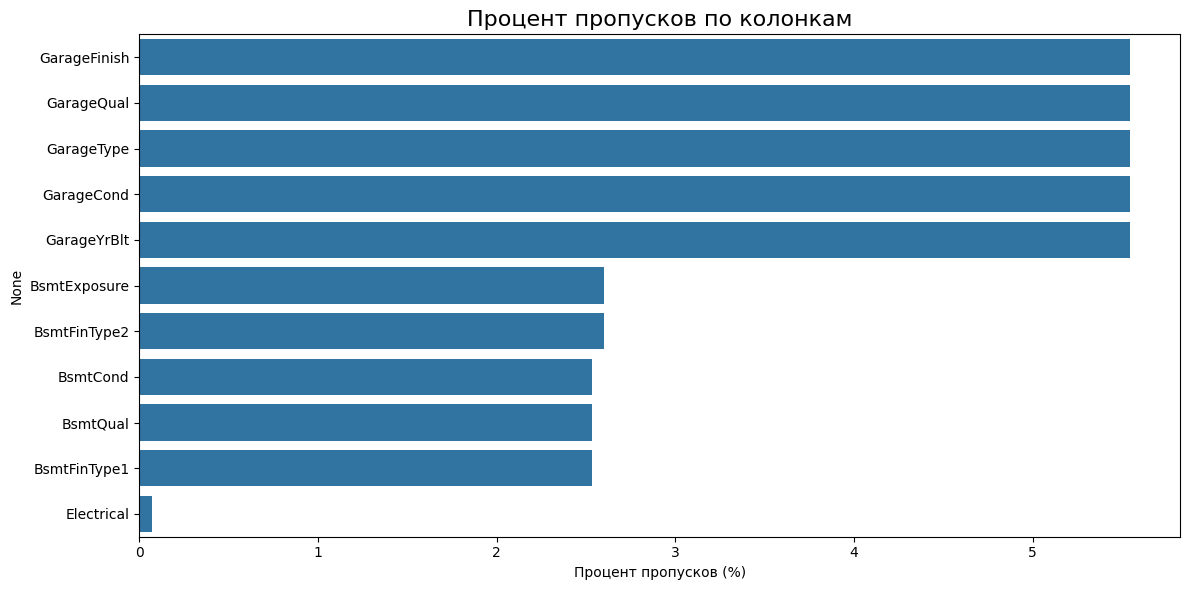

In [12]:
# Повторный анализ пропусков (визуализация)
analyze_missings(df_clean)

In [13]:
# Все колонки связанные с гаражом
garage_columns = ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 
                  'GarageArea', 'GarageQual', 'GarageCond']

print("АНАЛИЗ ГАРАЖНЫХ ПРИЗНАКОВ")

# 1. Базовый обзор
print("\n1. Пропуски в гаражных признаках:")
garage_missing = df[garage_columns].isnull().sum()
print(garage_missing)

# 2. Проверим, всегда ли пропуски идут вместе
print("\n2. Анализ совместных пропусков:")
# Создадим маску - где есть пропуски в любом гаражном признаке
garage_null_mask = df[garage_columns].isnull().any(axis=1)
print(f"Домов с пропусками в гараже: {garage_null_mask.sum()}")

# Посмотрим на уникальные комбинации пропусков
null_patterns = df[garage_columns].isnull().drop_duplicates()
print(f"\nУникальные паттерны пропусков ({len(null_patterns)}):")
print(null_patterns)

# 3. Связь с другими признаками
print("\n3. Есть ли гараж вообще? (GarageArea = 0)")
no_garage = df[df['GarageArea'] == 0]
print(f"Домов с GarageArea = 0: {len(no_garage)}")
print(f"Из них имеют пропуски в других гаражных полях: {(no_garage[garage_columns].isnull().any(axis=1)).sum()}")

АНАЛИЗ ГАРАЖНЫХ ПРИЗНАКОВ

1. Пропуски в гаражных признаках:
GarageType      81
GarageYrBlt     81
GarageFinish    81
GarageCars       0
GarageArea       0
GarageQual      81
GarageCond      81
dtype: int64

2. Анализ совместных пропусков:
Домов с пропусками в гараже: 81

Уникальные паттерны пропусков (2):
    GarageType  GarageYrBlt  GarageFinish  GarageCars  GarageArea  GarageQual  \
0        False        False         False       False       False       False   
39        True         True          True       False       False        True   

    GarageCond  
0        False  
39        True  

3. Есть ли гараж вообще? (GarageArea = 0)
Домов с GarageArea = 0: 81
Из них имеют пропуски в других гаражных полях: 81


In [14]:
no_garage_mask = df_clean['GarageArea'] == 0
print(f"Домов без гаража: {no_garage_mask.sum()}")

# Заполняем все категориальные признаки для домов без гаража
garage_cat_cols = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
for col in garage_cat_cols:
    df_clean.loc[no_garage_mask, col] = 'NoGarage'

df_clean.loc[no_garage_mask, 'GarageYrBlt'] = 0
print(f"GarageYrBlt: заполнено 0 для {no_garage_mask.sum()} домов")

# Проверим, что GarageCars тоже 0 для этих домов (скорее всего уже 0)
if (df_clean.loc[no_garage_mask, 'GarageCars'] != 0).any():
    print("Внимание: есть дома с GarageArea=0, но GarageCars>0")
    df_clean.loc[no_garage_mask, 'GarageCars'] = 0
else:
    print("GarageCars уже корректно = 0")

Домов без гаража: 81
GarageYrBlt: заполнено 0 для 81 домов
GarageCars уже корректно = 0


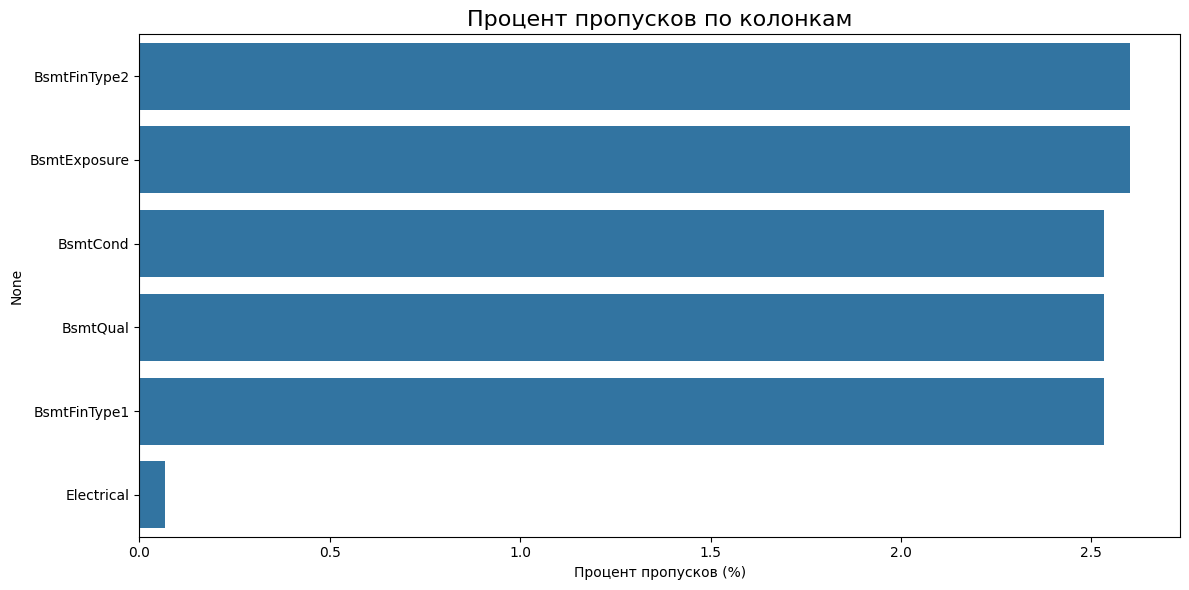

In [15]:
# Повторный анализ пропусков (визуализация)
analyze_missings(df_clean)

In [16]:
# Все колонки связанные с подвалом
bsmt_columns = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
                'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 
                'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']

print("="*60)
print("АНАЛИЗ ПОДВАЛЬНЫХ ПРИЗНАКОВ")
print("="*60)

# 1. Базовый обзор пропусков
print("\n1. Пропуски в подвальных признаках:")
bsmt_missing = df[bsmt_columns].isnull().sum()
print(bsmt_missing[bsmt_missing > 0])

# 2. Проверим площадь подвала
print("\n2. Анализ площади подвала:")
print(f"Домов с TotalBsmtSF = 0: {(df['TotalBsmtSF'] == 0).sum()}")
print(f"Домов с TotalBsmtSF > 0: {(df['TotalBsmtSF'] > 0).sum()}")

# 3. Паттерны пропусков
print("\n3. Паттерны пропусков в категориальных признаках подвала:")
bsmt_cat = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
null_patterns = df[bsmt_cat].isnull().drop_duplicates()
print(f"Уникальных паттернов: {len(null_patterns)}")
print(null_patterns)

# 4. Связь с площадью
print("\n4. Связь пропусков с площадью подвала:")
for col in bsmt_cat:
    null_mask = df[col].isnull()
    if null_mask.any():
        print(f"\n{col}:")
        print(f"  - Пропуски: {null_mask.sum()} домов")
        print(f"  - Из них с TotalBsmtSF = 0: {(null_mask & (df['TotalBsmtSF'] == 0)).sum()}")
        print(f"  - Из них с TotalBsmtSF > 0: {(null_mask & (df['TotalBsmtSF'] > 0)).sum()}")

АНАЛИЗ ПОДВАЛЬНЫХ ПРИЗНАКОВ

1. Пропуски в подвальных признаках:
BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
dtype: int64

2. Анализ площади подвала:
Домов с TotalBsmtSF = 0: 37
Домов с TotalBsmtSF > 0: 1423

3. Паттерны пропусков в категориальных признаках подвала:
Уникальных паттернов: 4
     BsmtQual  BsmtCond  BsmtExposure  BsmtFinType1  BsmtFinType2
0       False     False         False         False         False
17       True      True          True          True          True
332     False     False         False         False          True
948     False     False          True         False         False

4. Связь пропусков с площадью подвала:

BsmtQual:
  - Пропуски: 37 домов
  - Из них с TotalBsmtSF = 0: 37
  - Из них с TotalBsmtSF > 0: 0

BsmtCond:
  - Пропуски: 37 домов
  - Из них с TotalBsmtSF = 0: 37
  - Из них с TotalBsmtSF > 0: 0

BsmtExposure:
  - Пропуски: 38 домов
  - Из них с TotalBsmtSF = 0: 37
  - Из них с TotalB

In [17]:
# Посмотрим сколько строк с проблемами
print("Анализ проблемных строк с подвалом:")
print("="*50)

# Дома без подвала (нормальная ситуация, удалять не нужно)
no_bsmt = df['TotalBsmtSF'] == 0
print(f"Дома без подвала (не удаляем): {no_bsmt.sum()}")

# Дома с подвалом, но пропущенными характеристиками
has_bsmt_missing = (df['TotalBsmtSF'] > 0) & (
    df['BsmtQual'].isnull() | 
    df['BsmtCond'].isnull() | 
    df['BsmtExposure'].isnull() | 
    df['BsmtFinType1'].isnull()
)
print(f"Дома с подвалом и пропусками: {has_bsmt_missing.sum()}")

# Общее количество потенциально удаляемых строк
total_to_drop = has_bsmt_missing.sum()
print(f"\nПотенциально удаляемых строк: {total_to_drop}")
print(f"Это {total_to_drop/len(df)*100:.2f}% от всего датасета")


# Покажем проблемную строку
if has_bsmt_missing.any():
    print("\n🔍 Проблемная строка:")
    problem_row = df[has_bsmt_missing].index[0]
    print(df.loc[problem_row, ['TotalBsmtSF', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']])

Анализ проблемных строк с подвалом:
Дома без подвала (не удаляем): 37
Дома с подвалом и пропусками: 1

Потенциально удаляемых строк: 1
Это 0.07% от всего датасета

🔍 Проблемная строка:
TotalBsmtSF     936
BsmtQual         Gd
BsmtCond         TA
BsmtExposure    NaN
BsmtFinType1    Unf
BsmtFinType2    Unf
Name: 948, dtype: object


In [18]:
if has_bsmt_missing.any():
    rows_to_drop = df[has_bsmt_missing].index
    df_clean = df_clean.drop(index=rows_to_drop)
    print(f"Удалена 1 проблемная строка с индексом {rows_to_drop[0]}")
    
    # Для домов без подвала (нормальная ситуация) - помечаем 'NoBasement'
    no_bsmt_mask = df_clean['TotalBsmtSF'] == 0
    bsmt_cat_cols = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
    
    for col in bsmt_cat_cols:
        df_clean.loc[no_bsmt_mask, col] = 'NoBasement'

    print(f"\nПомечено 'NoBasement' для {no_bsmt_mask.sum()} домов без подвала")
    

Удалена 1 проблемная строка с индексом 948

Помечено 'NoBasement' для 37 домов без подвала


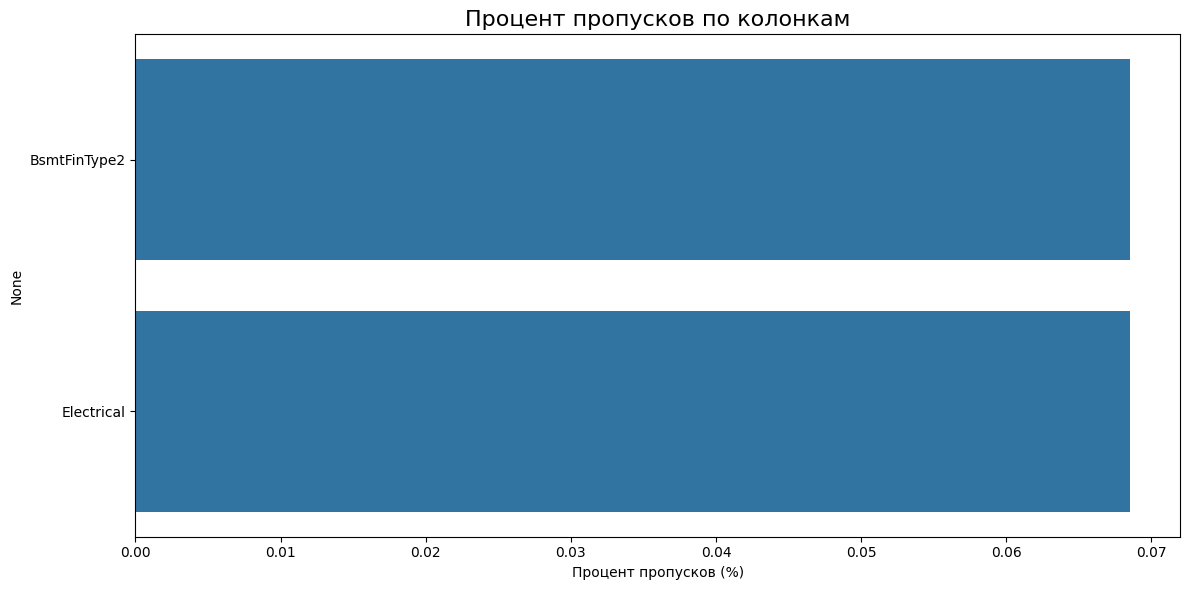

In [19]:
analyze_missings(df_clean)

In [20]:
df_clean = df_clean.drop(index = df_clean[df_clean['BsmtFinType2'].isna()].index)
df_clean = df_clean.drop(index = df_clean[df_clean['Electrical'].isna()].index)
analyze_missings(df_clean)

нет данных с пропусками


<Figure size 1200x600 with 0 Axes>

In [21]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1457 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1457 non-null   int64  
 1   MSSubClass     1457 non-null   int64  
 2   MSZoning       1457 non-null   object 
 3   LotFrontage    1457 non-null   float64
 4   LotArea        1457 non-null   int64  
 5   Street         1457 non-null   object 
 6   Alley          1457 non-null   object 
 7   LotShape       1457 non-null   object 
 8   LandContour    1457 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1457 non-null   object 
 11  LandSlope      1457 non-null   object 
 12  Neighborhood   1457 non-null   object 
 13  Condition1     1457 non-null   object 
 14  Condition2     1457 non-null   object 
 15  BldgType       1457 non-null   object 
 16  HouseStyle     1457 non-null   object 
 17  OverallQual    1457 non-null   int64  
 18  OverallCond  

In [23]:
# One-Hot Encoding для категориальных признаков
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(f"Размер после One-Hot Encoding: {df_encoded.shape}")

# Создание новых признаков
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBath'] = df['FullBath'] + 0.5 * df['HalfBath'] + df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath']
df['Age'] = df['YrSold'] - df['YearBuilt']
df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']

# Группировка редких категорий
df['MSZoning_grouped'] = df['MSZoning'].apply(lambda x: x if x in ['RL', 'RM'] else 'Other')

Размер после One-Hot Encoding: (1460, 252)


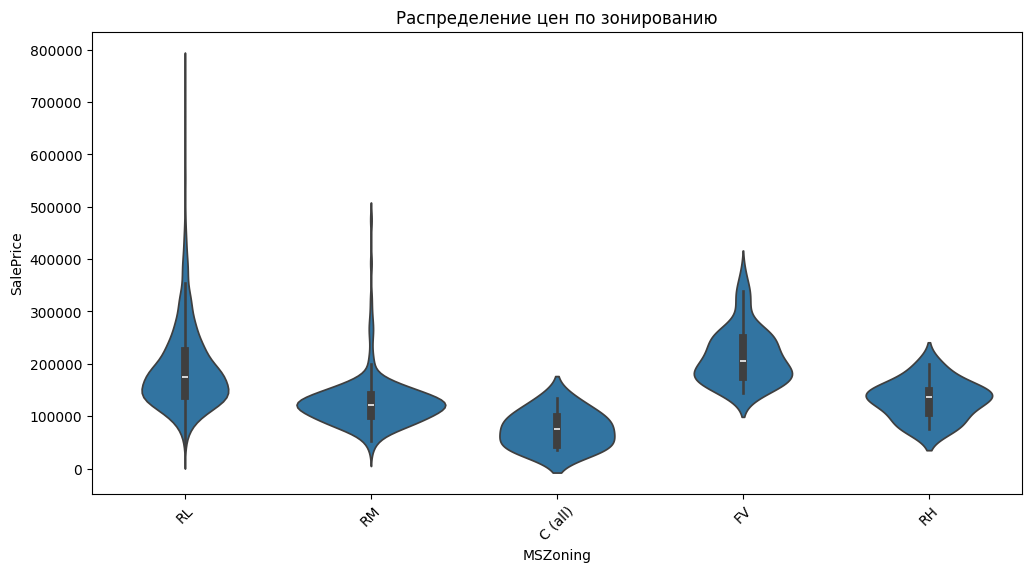

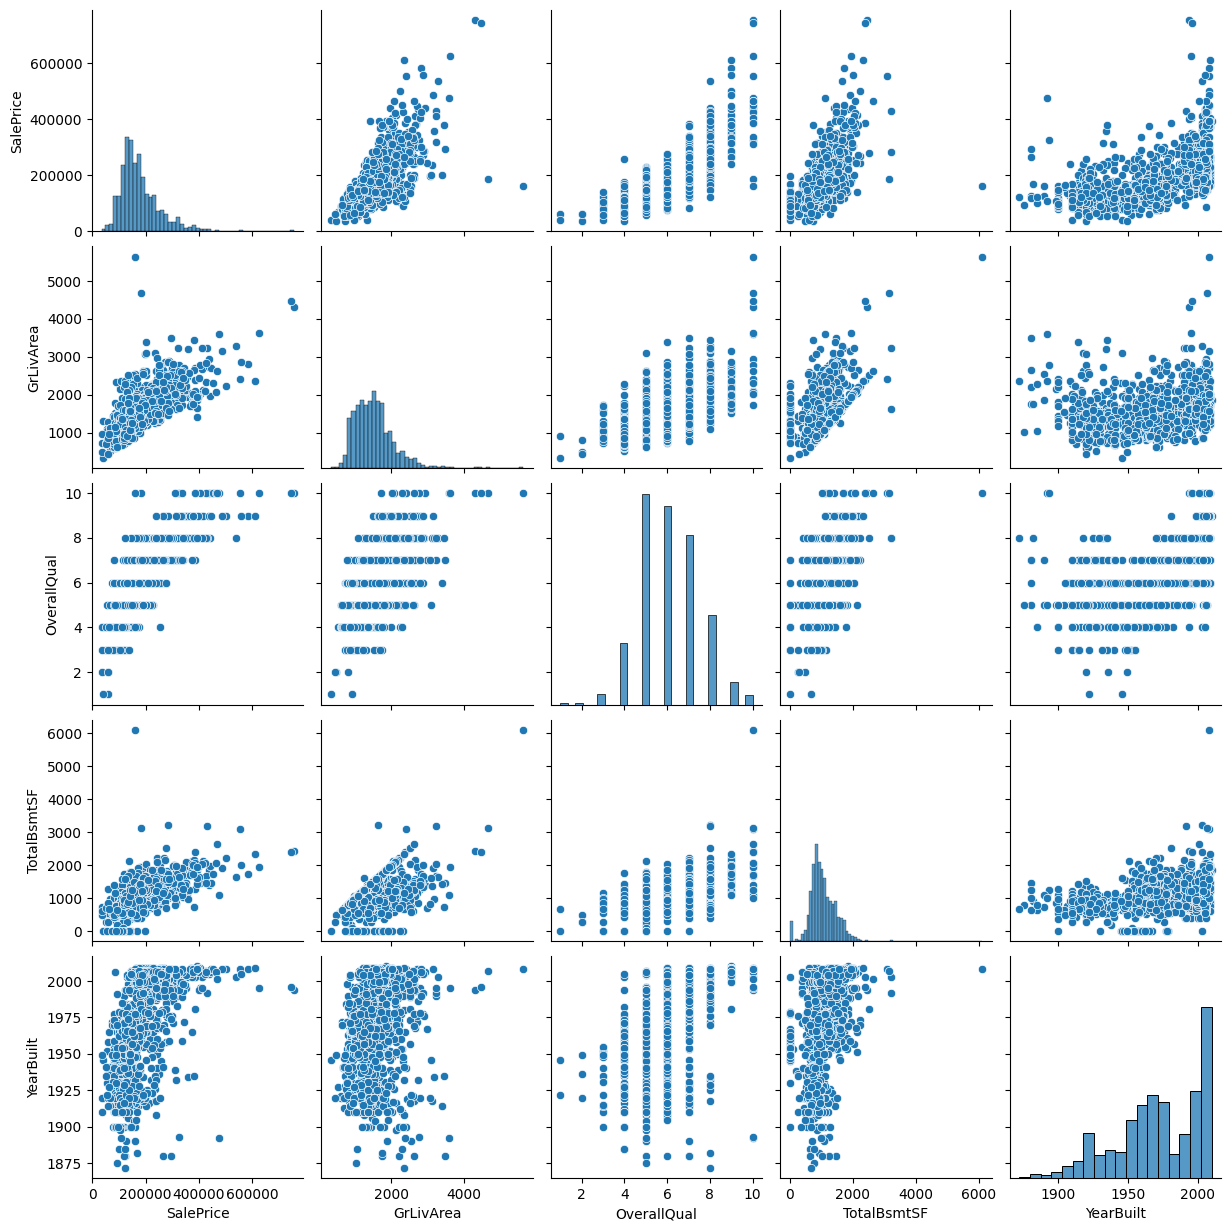

In [ ]:
# Violin plot для целевой переменной по категориям
plt.figure(figsize=(12, 6))
sns.violinplot(x='MSZoning', y='SalePrice', data=df)
plt.title('Распределение цен по зонированию')
plt.xticks(rotation=45)
plt.show()

# Pairplot для ключевых признаков (можно ограничить)
sns.pairplot(df[['SalePrice', 'GrLivArea', 'OverallQual', 'TotalBsmtSF', 'YearBuilt']])
plt.show()

# Интерактивный Plotly график
fig = px.scatter(df, x='GrLivArea', y='SalePrice', 
                 color='OverallQual', 
                 hover_data=['Neighborhood', 'YearBuilt'],
                 title='Зависимость цены от жилой площади')
fig.show()

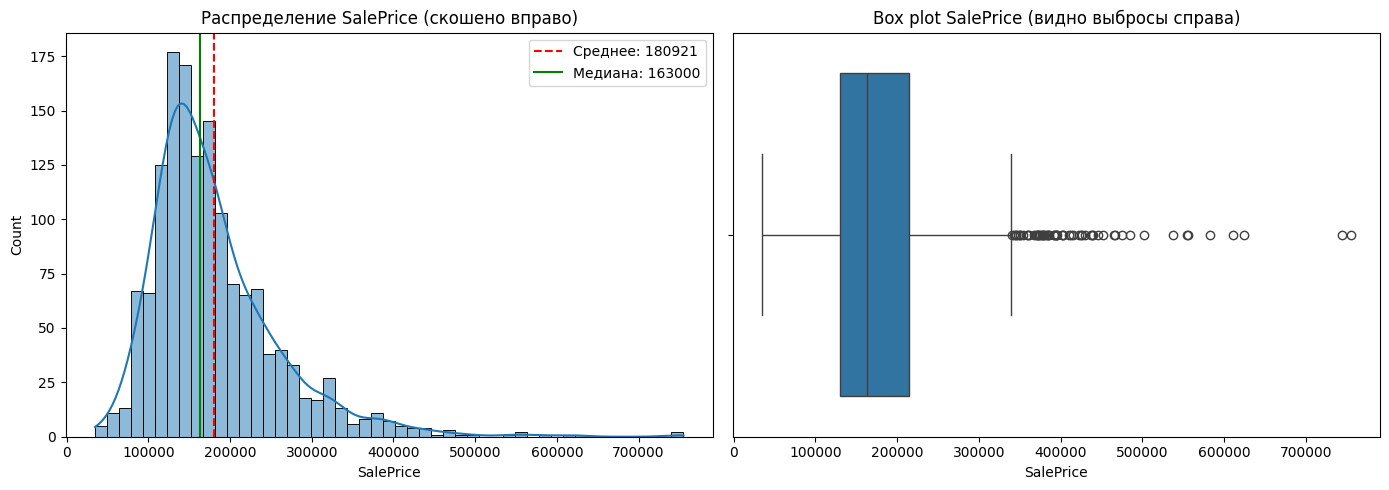

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма с KDE
sns.histplot(df['SalePrice'], kde=True, ax=axes[0])
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f'Среднее: {df["SalePrice"].mean():.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linestyle='-', label=f'Медиана: {df["SalePrice"].median():.0f}')
axes[0].set_title('Распределение SalePrice')
axes[0].legend()

# Box plot для наглядности выбросов
sns.boxplot(x=df['SalePrice'], ax=axes[1])
axes[1].set_title('Box plot SalePrice')

plt.tight_layout()
plt.show()

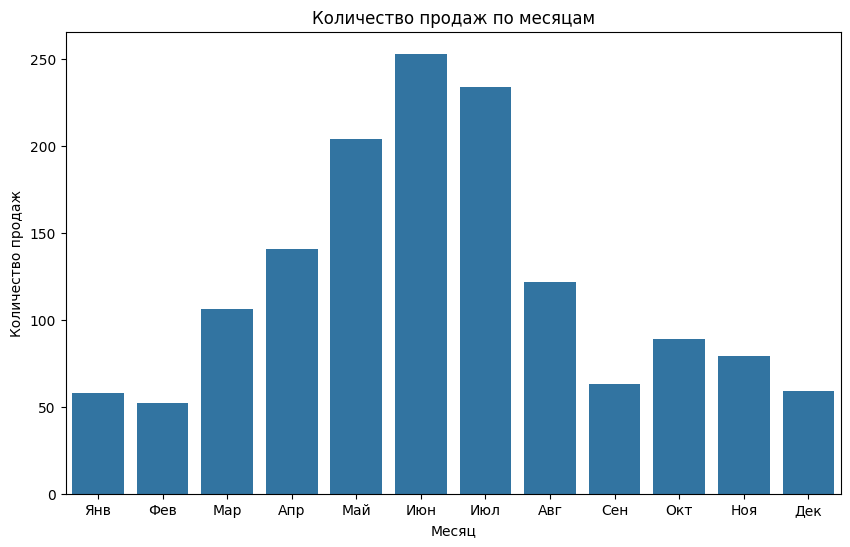

In [33]:
# График 1: Количество продаж по месяцам
# Простой вариант
plt.figure(figsize=(10, 6))
sns.countplot(x='MoSold', data=df, order=range(1, 13))
plt.title('Количество продаж по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество продаж')
plt.xticks(ticks=range(12), labels=['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
                                     'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
plt.show()

## Итоговые выводы

### Что я понял про датасет:
1. Датасет содержит 1460 наблюдений и 81 признак
2. Целевая переменная SalePrice имеет асимметричное распределение
3. Наиболее значимые корреляции с ценой: OverallQual, GrLivArea, TotalBsmtSF
4. Многие категориальные признаки имеют "NoBasement"/"NoGarage" значения
5. Пропуски в основном означают отсутствие объекта (бассейн, гараж, подвал)
6. Есть выбросы по площади жилья (GrLivArea > 4000)
7. Дома с более высоким качеством отделки (ExterQual, KitchenQual) продаются дороже
8. Сезонность продаж: пик продаж приходится на май-июнь
9. Новые дома (YearBuilt ближе к 2010) имеют более высокую цену
10. Расположение (Neighborhood) сильно влияет на стоимость

### Гипотезы и наблюдения:
1. **Гипотеза 1**: Дома с подвалом (BsmtFinSF1 > 0) продаются дороже, чем без подвала
2. **Гипотеза 2**: Качество материалов (OverallQual) — лучший предиктор цены
3. **Гипотеза 3**: Выбросы по площади (>4000 кв.футов) — это особняки, требующие отдельного анализа

### Следующие шаги:
1. **Предсказание цены дома** — регрессионная задача
2. **Модели для проб**: 
   - Linear Regression (базовый уровень)
   - Random Forest Regressor (для учета нелинейностей)
   - XGBoost/LightGBM (для высокого качества)


## Использование AI-помощников

В ходе выполнения EDA я использовал AI-помощников для:
**Понимания методов обработки пропусков** — когда уместно использовать median vs mean
**Feature Engineering** — получил идеи для создания новых признаков (TotalBath, Age)

**Выбора визуализаций** — узнал о violin plot и его преимуществах перед box plot

**Что проверял/дописывал руками:**
- Проверял логику заполнения пропусков (гараж/подвал)
- Анализировал конкретные выбросы в данных
- Корректировал выбор признаков для визуализаций